In [4151]:
# 1. Pull BTC spot price and volume data

import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os

load_dotenv()

url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"

params = {
    "vs_currency": "usd",
    "days": 365,
    "interval": "daily"
}

response = requests.get(url, params=params)

response.raise_for_status()

data = response.json()

In [4152]:
prices_raw = pd.DataFrame(
    data['prices'],
    columns=['timestamp', 'price']
)

prices = prices_raw.copy()

prices['datetime'] = pd.to_datetime(
    prices['timestamp'],
    unit='ms',
    utc=True
)

prices['date'] = prices['datetime'].dt.normalize()

In [4153]:
prices = prices[
    prices['datetime'].dt.time
    == pd.Timestamp('00:00:00').time()
].copy()

In [4154]:
# Set date index
prices = prices.set_index('date')

# Ensure daily series is contiguous
assert (
    prices.index.to_series().diff().dropna()
    == pd.Timedelta(days=1)
).all(), "Missing dates detected in price series"

In [4155]:
prices['daily_return'] = prices['price'].pct_change().fillna(0)
prices['7d_return'] = prices['price'].pct_change(7)
prices['30d_return'] = prices['price'].pct_change(30)

In [4156]:
print(prices[['price', 'daily_return', '7d_return']].tail(10))

                                  price  daily_return  7d_return
date                                                            
2026-06-01 00:00:00+00:00  73593.371197     -0.002138  -0.044095
2026-06-02 00:00:00+00:00  71360.325213     -0.030343  -0.076533
2026-06-03 00:00:00+00:00  66649.855619     -0.066010  -0.120993
2026-06-04 00:00:00+00:00  64021.889159     -0.039429  -0.138943
2026-06-05 00:00:00+00:00  63796.254392     -0.003524  -0.132494
2026-06-06 00:00:00+00:00  60921.794415     -0.045057  -0.169807
2026-06-07 00:00:00+00:00  60861.880129     -0.000983  -0.174766
2026-06-08 00:00:00+00:00  63254.572151      0.039313  -0.140485
2026-06-09 00:00:00+00:00  63078.440495     -0.002784  -0.116057
2026-06-10 00:00:00+00:00  61658.311991     -0.022514  -0.074892


In [4157]:
prices['rolling_vol_7d'] = prices['daily_return'].rolling(7).std()

In [4158]:
prices['ma_7'] = prices['price'].rolling(7).mean()
prices['ma_30'] = prices['price'].rolling(30).mean()

In [4159]:
prices['signal'] = 'Neutral'

prices.loc[prices['7d_return'] > 0.05, 'signal'] = 'Strong Momentum'
prices.loc[prices['7d_return'] < -0.05, 'signal'] = 'Weak Momentum'

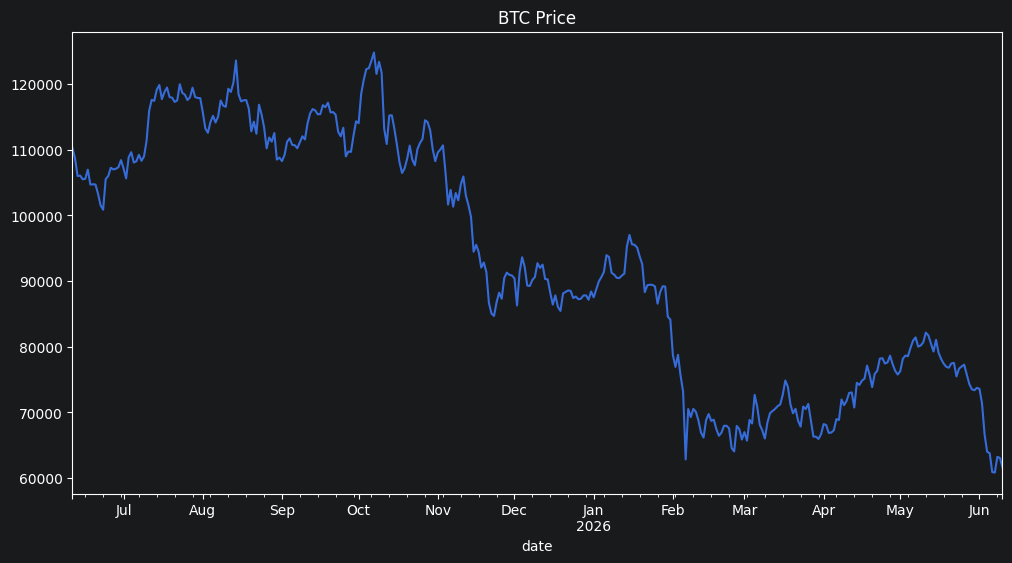

In [4160]:
prices['price'].plot(figsize=(12,6))
plt.title('BTC Price')
plt.show()

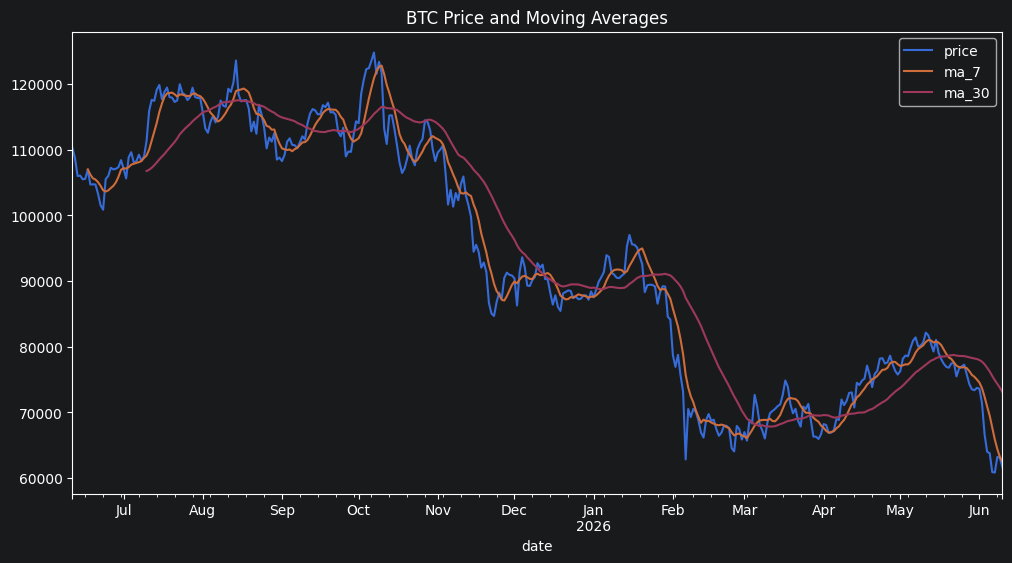

In [4161]:
prices[['price','ma_7', 'ma_30']].plot(figsize=(12,6))
plt.title('BTC Price and Moving Averages')
plt.show()

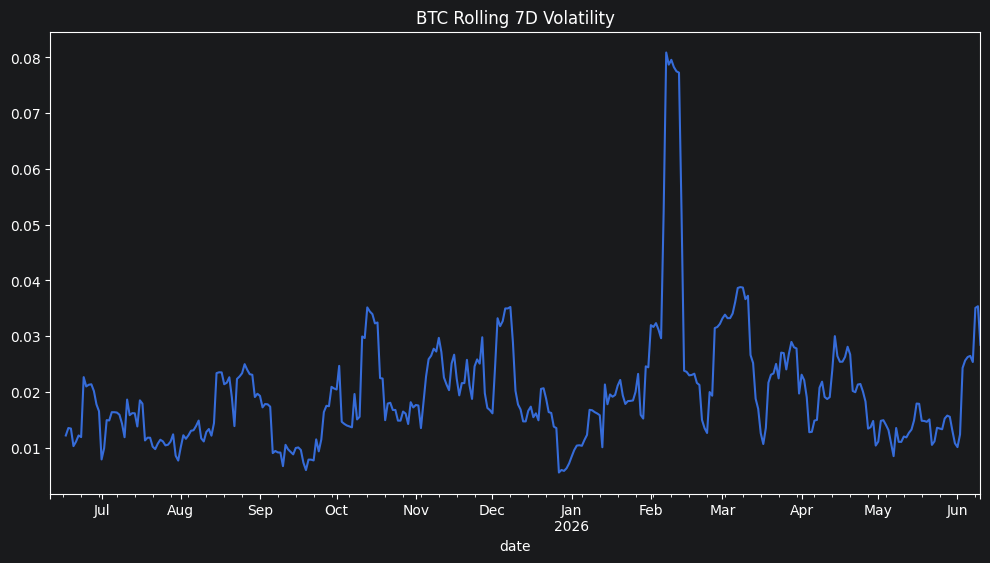

In [4162]:
prices['rolling_vol_7d'].plot(figsize=(12,6))
plt.title('BTC Rolling 7D Volatility')
plt.show()

In [4163]:
volumes_raw = pd.DataFrame(
    data['total_volumes'],
    columns=['timestamp', 'volume']
)

volumes = volumes_raw.copy()

volumes['datetime'] = pd.to_datetime(
    volumes['timestamp'],
    unit='ms',
    utc=True
)

volumes = volumes[
    volumes['datetime'].dt.time == pd.Timestamp('00:00:00').time()
].copy()

volumes['date'] = volumes['datetime'].dt.normalize()

volumes = volumes[['date', 'volume']]

In [4164]:
prices = prices.merge(volumes, on='date', how='left', validate='one_to_one')
prices = prices.set_index('date')

In [4165]:
prices['volumes_ma_7'] = prices['volume'].rolling(7).mean()

In [4166]:
prices['volume_signal'] = 'normal'

prices.loc[
    prices['volume'] > prices['volumes_ma_7']*1.5,
    'volume_signal'
] = 'Elevated Activity'

In [4167]:
volume_mean = prices['volume'].rolling(30).mean()
volume_std = prices['volume'].rolling(30).std()
prices['volume_zscore'] = (prices['volume'] - volume_mean) / volume_std

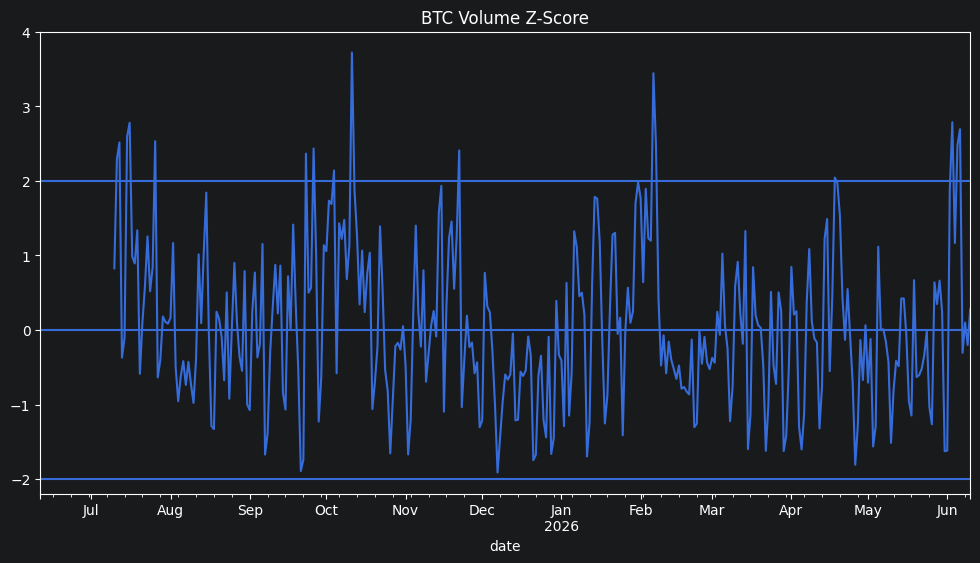

In [4168]:
prices['volume_zscore'].plot(figsize=(12,6))
plt.axhline(0)
plt.axhline(2)
plt.axhline(-2)
plt.title('BTC Volume Z-Score')
plt.show()

In [4169]:
# Create spot participation signals

prices['spot_participation_signal'] = 'Neutral'

prices.loc[
    (prices['7d_return'] > 0.05) &
     (prices['volume_zscore'] > 1),
    'spot_participation_signal'
] = 'Strong Spot Participation'

prices.loc[
    (prices['7d_return'] < -0.05) &
    (prices['volume_zscore'] > 1),
    'spot_participation_signal'
] = 'High-Volume Selloff'

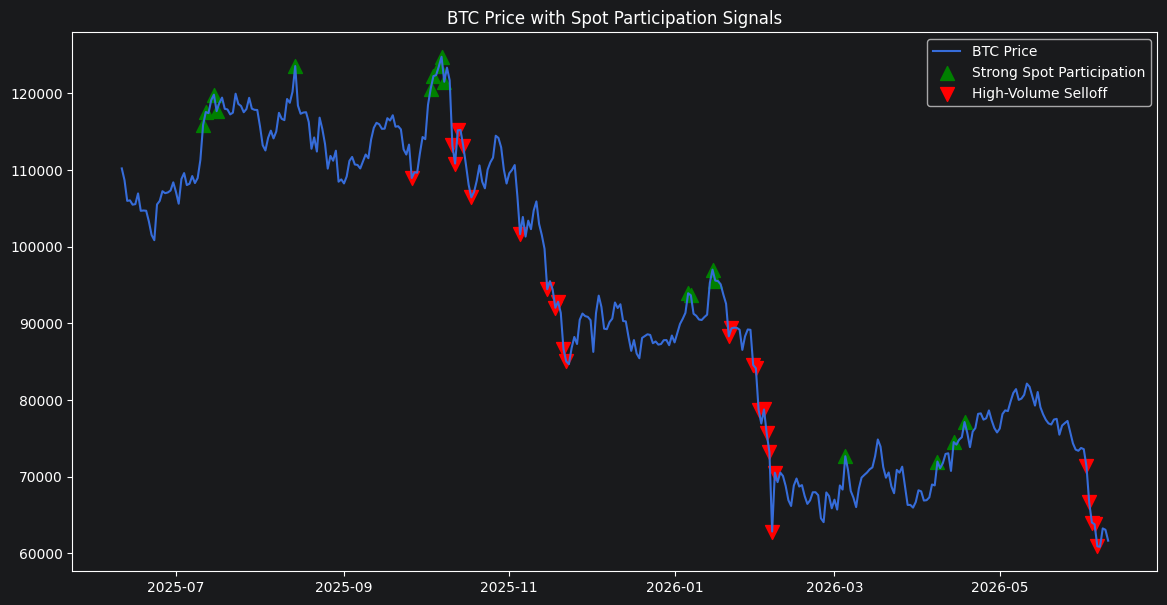

In [4170]:
strong_spot_participation = prices[prices['spot_participation_signal'] == 'Strong Spot Participation']
high_volume_selloff = prices[prices['spot_participation_signal'] == 'High-Volume Selloff']

plt.figure(figsize=(14,7))

plt.plot(prices.index,
    prices['price'],
    label='BTC Price'
)

plt.scatter(strong_spot_participation.index, strong_spot_participation['price'], label = 'Strong Spot Participation', marker = '^', color = 'green', s = 100)

plt.scatter(high_volume_selloff.index, high_volume_selloff['price'], label = 'High-Volume Selloff', marker = 'v', color = 'red', s = 100)

plt.title('BTC Price with Spot Participation Signals')
plt.legend()
plt.show()

In [4171]:
# 2. Pull BTC funding rates

hl_url = "https://api.hyperliquid.xyz/info"

end_time = int(time.time() * 1000)
start_time = end_time - (365 * 24 * 60 * 60 * 1000)

all_funding_data = []
current_start = start_time

while current_start < end_time:
    payload = {
        "type": "fundingHistory",
        "coin": "BTC",
        "startTime": current_start,
        "endTime": end_time
    }

    response = requests.post(hl_url, json=payload)
    response.raise_for_status()

    batch = response.json()

    if len(batch) == 0:
        break

    all_funding_data.extend(batch)

    last_time = batch[-1]['time']
    current_start = last_time + 1

    time.sleep(0.5)

In [4172]:
funding_raw = pd.DataFrame(all_funding_data)
funding = funding_raw.copy()

funding['time'] = pd.to_datetime(
    funding['time'],
    unit='ms',
    utc=True
)

funding['fundingRate'] = pd.to_numeric(funding['fundingRate'])

funding = funding.rename(columns={
    'time':'date',
    'fundingRate':'funding_rate'
})

funding = funding[['date', 'funding_rate']]

funding = funding.set_index('date')

daily_funding = funding.resample('D').mean()

In [4173]:
prices = prices.merge(daily_funding, on='date', how='left', validate='one_to_one')

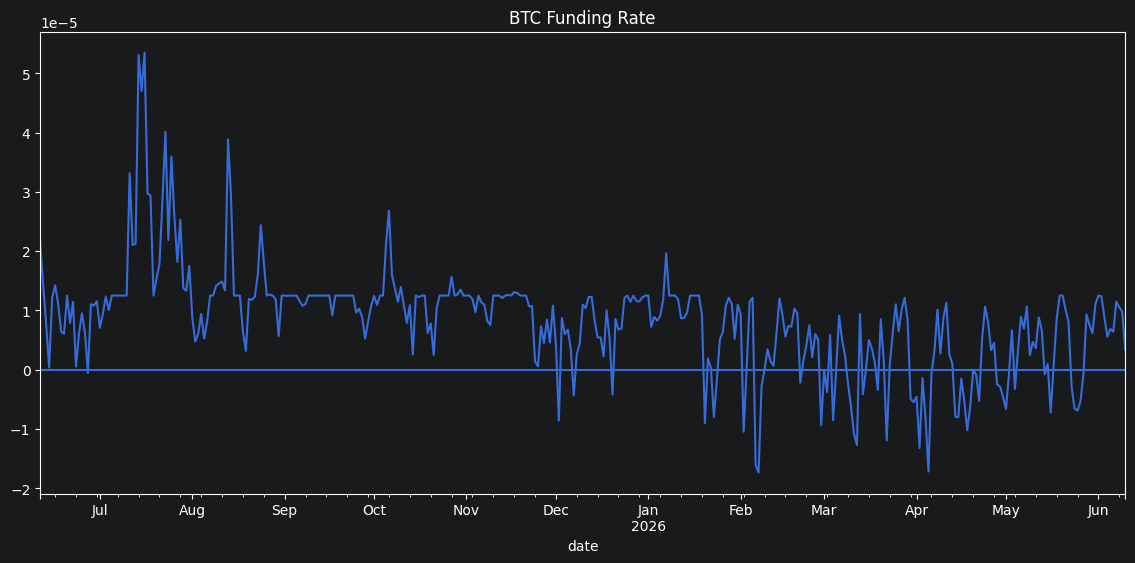

In [4174]:
prices['funding_rate'].plot(figsize=(14,6))
plt.axhline(0)
plt.title('BTC Funding Rate')
plt.show()

In [4175]:
prices['funding_ma_7d'] = prices['funding_rate'].rolling(7).mean()

Text(0.5, 1.0, 'BTC 7D Average Funding')

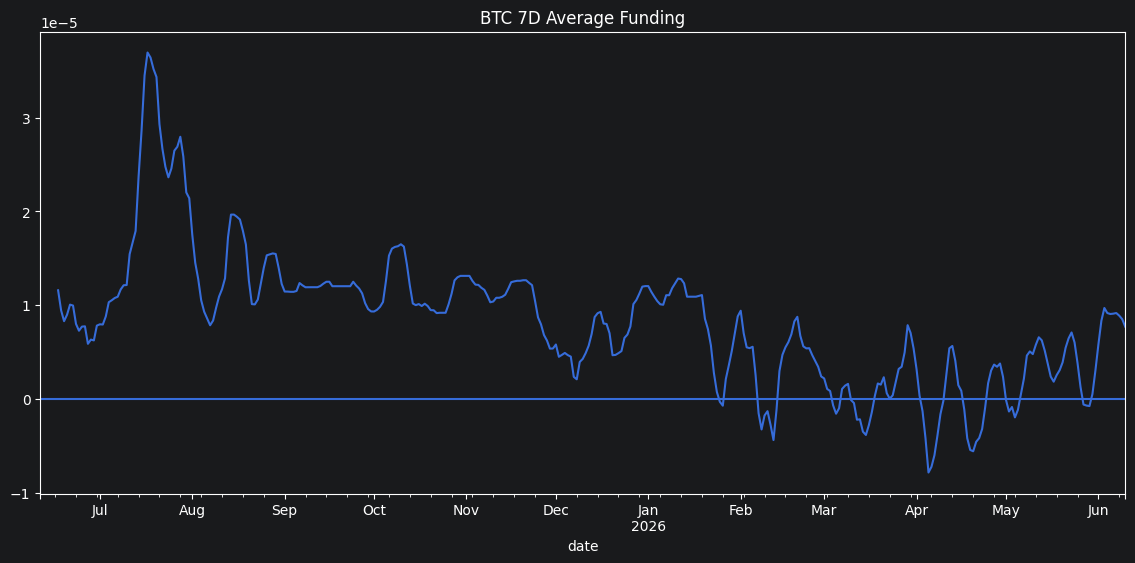

In [4176]:
prices['funding_ma_7d'].plot(figsize=(14,6))
plt.axhline(0)
plt.title('BTC 7D Average Funding')

In [4177]:
funding_mean = prices['funding_rate'].rolling(30).mean()
funding_std = prices['funding_rate'].rolling(30).std()
prices['funding_zscore'] = (prices['funding_rate'] - funding_mean) / funding_std

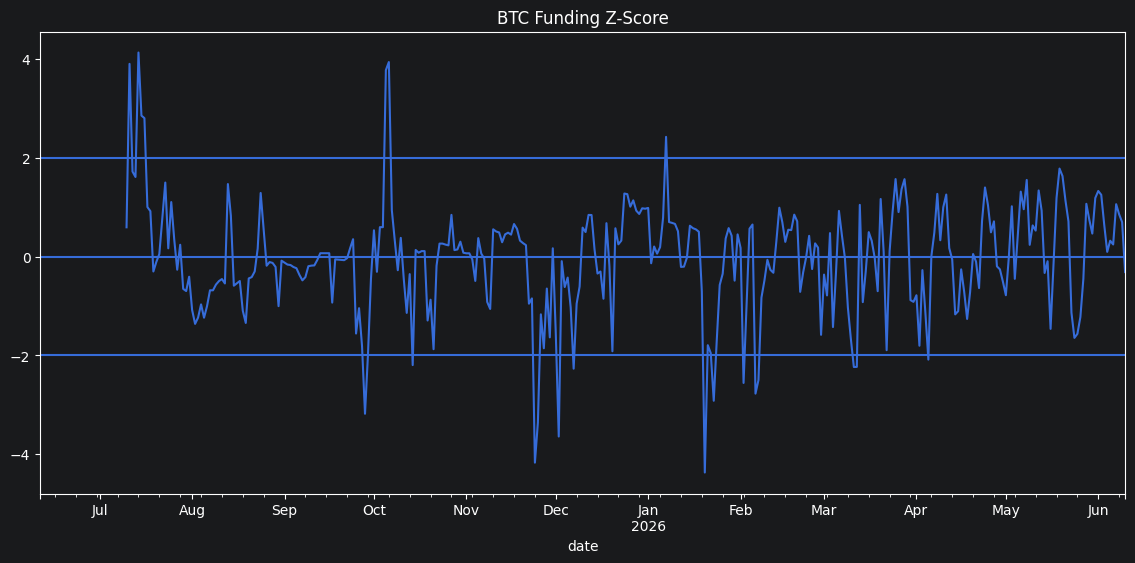

In [4178]:
prices['funding_zscore'].plot(figsize=(14,6))
plt.axhline(0)
plt.axhline(2)
plt.axhline(-2)
plt.title('BTC Funding Z-Score')
plt.show()

In [4179]:
# Create Funding/Leverage Signals

prices['funding_signal'] = 'Neutral'

prices.loc[
    prices['funding_zscore'] > 2,
    'funding_signal'
] = 'Crowded Longs'

prices.loc[
    prices['funding_zscore'] < -2,
    'funding_signal'
] = 'Crowded Shorts'

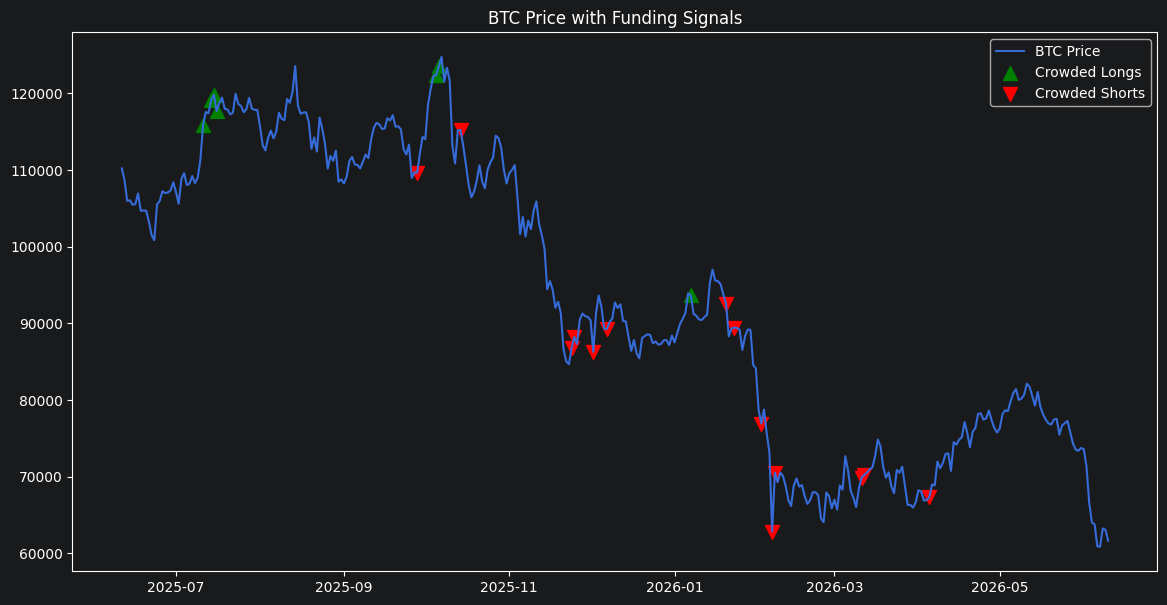

In [4180]:
# BTC Price with Funding Positioning Signals

crowded_longs = prices[
    prices['funding_signal'] == 'Crowded Longs'
]

crowded_shorts = prices[
    prices['funding_signal'] == 'Crowded Shorts'
]

plt.figure(figsize=(14,7))

# BTC Price Line
plt.plot(prices.index, prices['price'], label='BTC Price')

# Crowded Longs
plt.scatter(crowded_longs.index, crowded_longs['price'], label='Crowded Longs', marker='^', color='green', s=100)

#Crowded Shorts
plt.scatter(crowded_shorts.index, crowded_shorts['price'], label='Crowded Shorts', marker='v', color='red', s=100)

plt.title('BTC Price with Funding Signals')
plt.legend()
plt.show()

In [4181]:
# 3. Pull BTC open interest

coinglass_url = (
    "https://open-api-v4.coinglass.com"
    "/api/futures/open-interest/history"
)

headers = {
    "accept": "application/json",
    "CG-API-KEY": os.getenv("COINGLASS_API_KEY")
}

params = {
    "exchange": "Binance",
    "symbol": "BTCUSDT",
    "interval": "1d"
}

response = requests.get(
    coinglass_url,
    headers=headers,
    params=params
)

oi_data = response.json()

In [4182]:
oi = pd.DataFrame(oi_data['data'])

oi['time'] = pd.to_datetime(
    oi['time'],
    unit='ms',
    utc=True
)

oi[['open', 'high', 'low', 'close']] = oi[['open', 'high', 'low', 'close']].astype(float)

oi = oi.rename(columns={
    'time':'date',
    'open':'oi_open',
    'high':'oi_high',
    'low':'oi_low',
    'close':'oi_close'
})

oi = oi[['date', 'oi_open', 'oi_high', 'oi_low', 'oi_close']]

oi = oi.set_index('date')

In [4183]:
prices = prices.merge(oi[['oi_close']], on='date', how='left', validate='one_to_one')

In [4184]:
# Open Interest Analytics

prices['oi_daily_change'] = prices['oi_close'].pct_change()

prices['oi_7d_change'] = prices['oi_close'].pct_change(7)
prices['oi_30d_change'] = prices['oi_close'].pct_change(30)

In [4185]:
oi_mean = prices['oi_close'].rolling(30).mean()
oi_std = prices['oi_close'].rolling(30).std()

prices['oi_zscore'] = (prices['oi_close'] - oi_mean) / oi_std

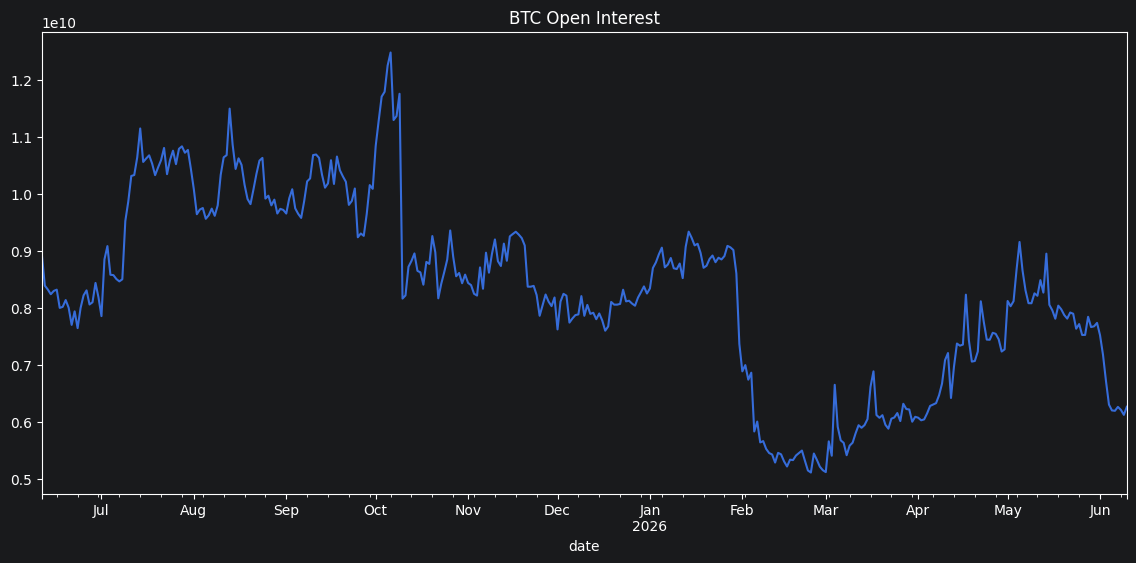

In [4186]:
# Open Interest Charts

prices['oi_close'].plot(figsize=(14,6))
plt.title('BTC Open Interest')
plt.show()

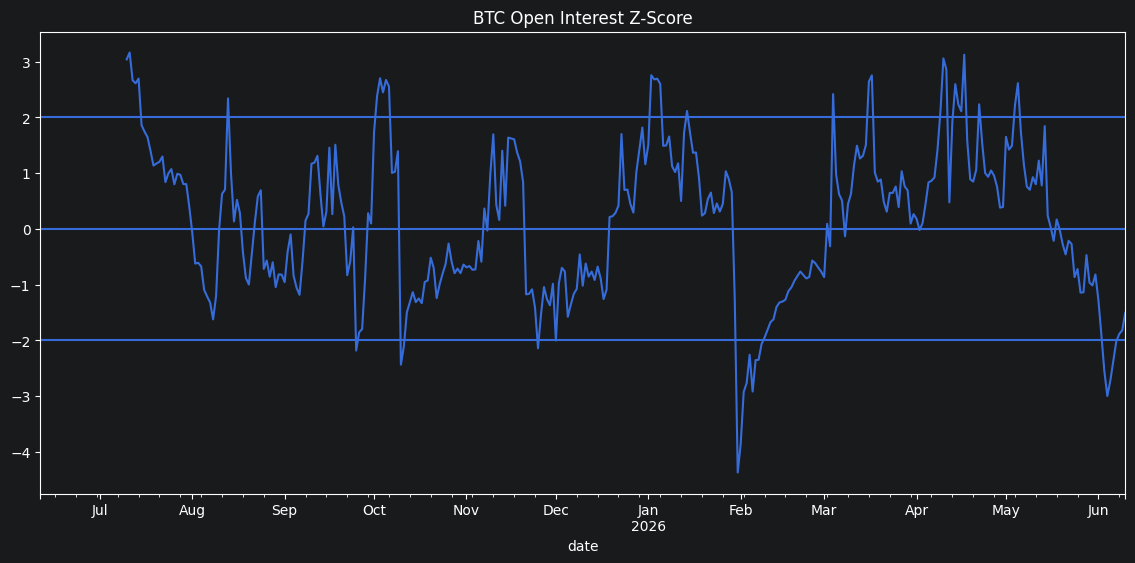

In [4187]:
prices['oi_zscore'].plot(figsize=(14,6))
plt.axhline(0)
plt.axhline(2)
plt.axhline(-2)
plt.title('BTC Open Interest Z-Score')
plt.show()

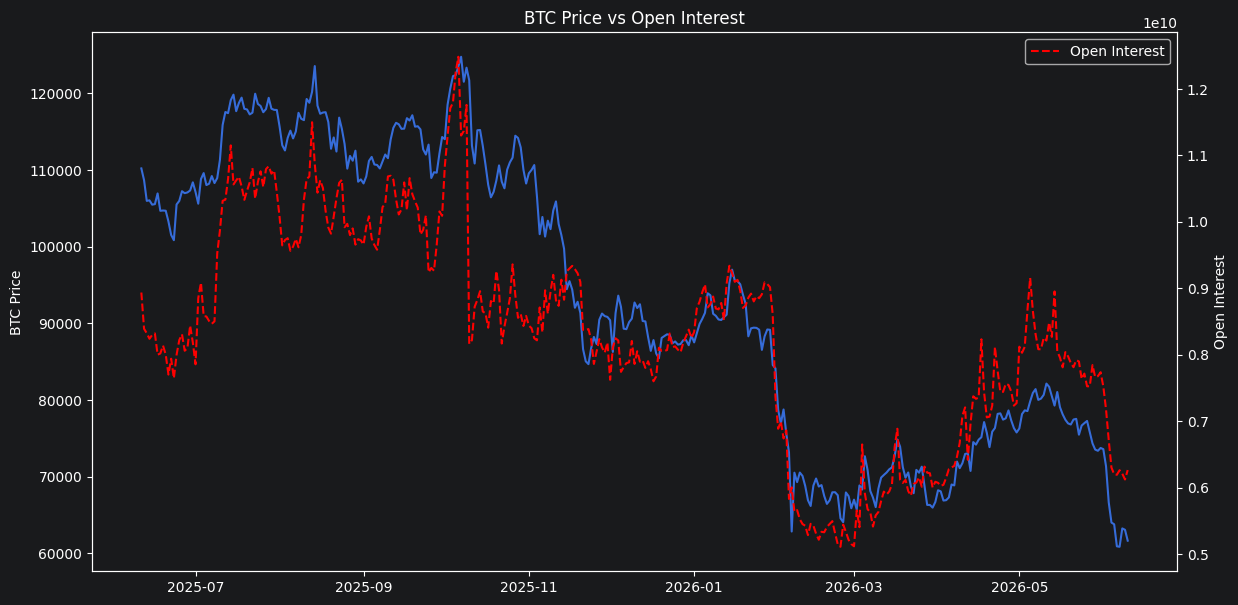

In [4188]:
fig, ax1 = plt.subplots(figsize=(14,7))

ax1.plot(prices.index, prices['price'], label='BTC Price')
ax1.set_ylabel('BTC Price')

ax2 = ax1.twinx()

ax2.plot(prices.index, prices['oi_close'], linestyle='--', label='Open Interest', color='red')
ax2.set_ylabel('Open Interest')

plt.title('BTC Price vs Open Interest')
plt.legend()
plt.show()

In [4189]:
# 4. Build positioning regimes

prices['leverage_signal'] = 'Neutral'

In [4190]:
# Aggressive Long Buildup
prices.loc[
    (prices['7d_return'] > 0.03) &
    (prices['funding_zscore'] > 0.5) &
    (prices['oi_7d_change'] > 0),
    'leverage_signal'
] = 'Aggressive Long Buildup'

# Short Covering Rally
prices.loc[
    (prices['7d_return'] > 0.03) &
    (prices['oi_7d_change'] < 0),
    'leverage_signal'
] = 'Short Covering Rally'

#Aggressive Short Buildup
prices.loc[
    (prices['7d_return'] < -0.03) &
    (prices['funding_zscore'] < -0.5) &
    (prices['oi_7d_change'] > 0),
    'leverage_signal'
] = 'Aggressive Short Buildup'

# Long Liquidation
prices.loc[
    (prices['7d_return'] < -0.07) &
    (prices['oi_7d_change'] < 0),
    'leverage_signal'
] = 'Long Liquidation'

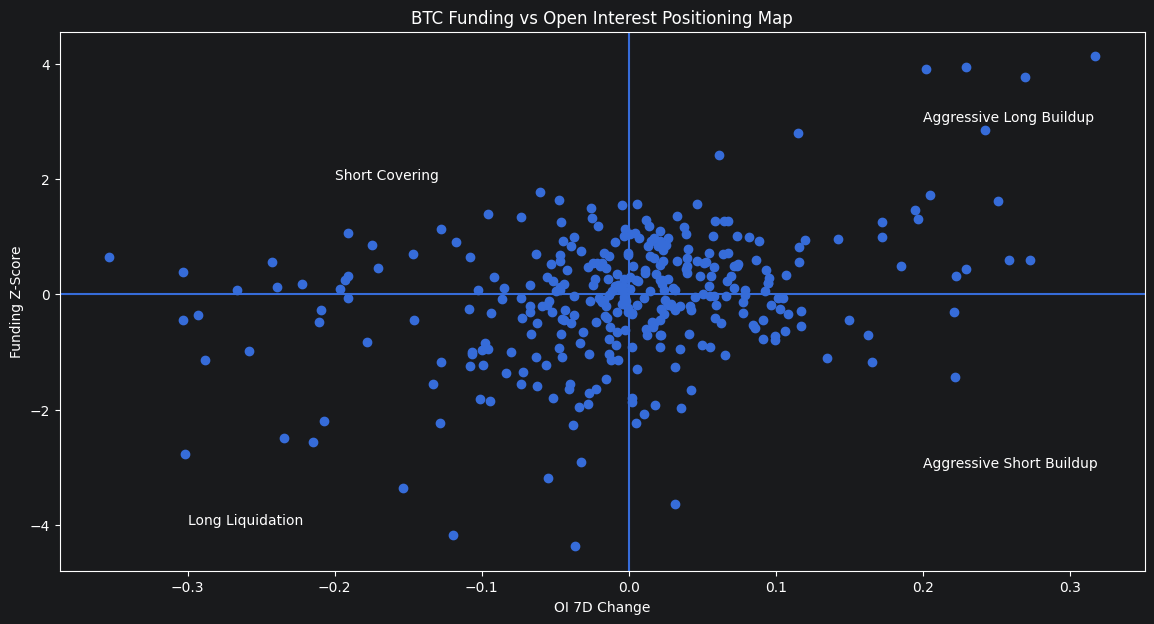

In [4191]:
# Funding z-score vs OI 7D change scatter

plt.figure(figsize=(14,7))

plt.scatter(prices['oi_7d_change'], prices['funding_zscore'])

plt.axhline(0)
plt.axvline(0)

# Quadrant Labels
plt.text(0.2, 3, 'Aggressive Long Buildup')
plt.text(0.2, -3, 'Aggressive Short Buildup')
plt.text(-0.2, 2, 'Short Covering')
plt.text(-0.3, -4, 'Long Liquidation')

plt.xlabel('OI 7D Change')
plt.ylabel('Funding Z-Score')
plt.title('BTC Funding vs Open Interest Positioning Map')

plt.show()

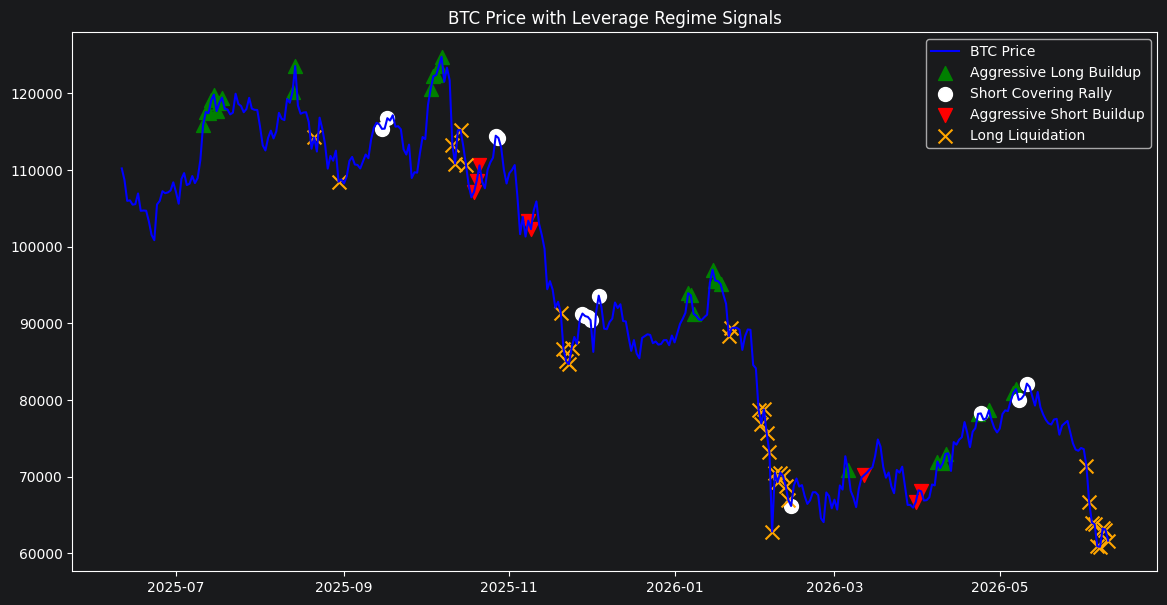

In [4192]:
# BTC Price with Leverage Regime Signals

long_buildup = prices[prices['leverage_signal'] == 'Aggressive Long Buildup']
short_covering = prices[prices['leverage_signal'] == 'Short Covering Rally']
short_buildup = prices[prices['leverage_signal'] == 'Aggressive Short Buildup']
long_liquidation = prices[prices['leverage_signal'] == 'Long Liquidation']

plt.figure(figsize=(14,7))

plt.plot(prices.index, prices['price'], label='BTC Price', color='blue')

plt.scatter(long_buildup.index, long_buildup['price'], label='Aggressive Long Buildup', marker='^', color='green', s=100)

plt.scatter(short_covering.index, short_covering['price'], label='Short Covering Rally', marker='o', color='white', s=100)

plt.scatter(short_buildup.index, short_buildup['price'], label='Aggressive Short Buildup', marker='v', color='red', s=100)

plt.scatter(long_liquidation.index, long_liquidation['price'], label='Long Liquidation', marker='x', color='orange', s=100)

plt.title('BTC Price with Leverage Regime Signals')
plt.legend()
plt.savefig(
    '../outputs/charts/leverage_regime_signals.png',
    bbox_inches='tight',
    dpi=300
)
plt.show()

In [4193]:
# 5. Pull BTC ETF flow data

etf_flow_url = (
    "https://open-api-v4.coinglass.com"
    "/api/etf/bitcoin/flow-history"
)

headers = {
    "accept": "application/json",
    "CG-API-KEY": os.getenv("COINGLASS_API_KEY")
}

response = requests.get(
    etf_flow_url,
    headers=headers
)

etf_flow_data = response.json()

In [4194]:
etf_flows = pd.DataFrame(etf_flow_data['data'])

etf_flows['timestamp'] = pd.to_datetime(
    etf_flows['timestamp'],
    unit='ms',
    utc=True
)

etf_flows = etf_flows.rename(columns={
    'timestamp':'date',
    'flow_usd':'btc_etf_flow_usd',
    'price_usd':'btc_etf_price_usd'
})

etf_flows = etf_flows[
    ['date', 'btc_etf_flow_usd', 'btc_etf_price_usd']
]

etf_flows = etf_flows.set_index('date')

In [4195]:
# ETF Flow Metrics

etf_flows['btc_etf_flow_7d'] = etf_flows['btc_etf_flow_usd'].rolling(7).sum()
etf_flows['btc_etf_flow_30d'] = etf_flows['btc_etf_flow_usd'].rolling(30).sum()

In [4196]:
etf_flow_mean = etf_flows['btc_etf_flow_usd'].rolling(30).mean()
etf_flow_std = etf_flows['btc_etf_flow_usd'].rolling(30).std()

etf_flows['btc_etf_flow_zscore'] = (etf_flows['btc_etf_flow_usd'] - etf_flow_mean) / etf_flow_std

In [4197]:
# Filter dataset for trailing 365 days

cutoff_date = pd.Timestamp.now(tz='UTC') - pd.Timedelta(days=365)

etf_flows_recent = etf_flows[
    etf_flows.index >= cutoff_date
].copy()

In [4198]:
print(etf_flows.tail())

                           btc_etf_flow_usd  btc_etf_price_usd  \
date                                                             
2026-06-04 00:00:00+00:00         3200000.0            64117.7   
2026-06-05 00:00:00+00:00      -325700000.0            63853.4   
2026-06-08 00:00:00+00:00       -91400000.0            63299.0   
2026-06-09 00:00:00+00:00       -77400000.0            63057.9   
2026-06-10 00:00:00+00:00               0.0            61694.9   

                           btc_etf_flow_7d  btc_etf_flow_30d  \
date                                                           
2026-06-04 00:00:00+00:00    -2.478300e+09     -4.031600e+09   
2026-06-05 00:00:00+00:00    -2.070600e+09     -4.580600e+09   
2026-06-08 00:00:00+00:00    -1.938700e+09     -4.686400e+09   
2026-06-09 00:00:00+00:00    -1.890800e+09     -4.500600e+09   
2026-06-10 00:00:00+00:00    -1.407000e+09     -4.410900e+09   

                           btc_etf_flow_zscore  
date                                   

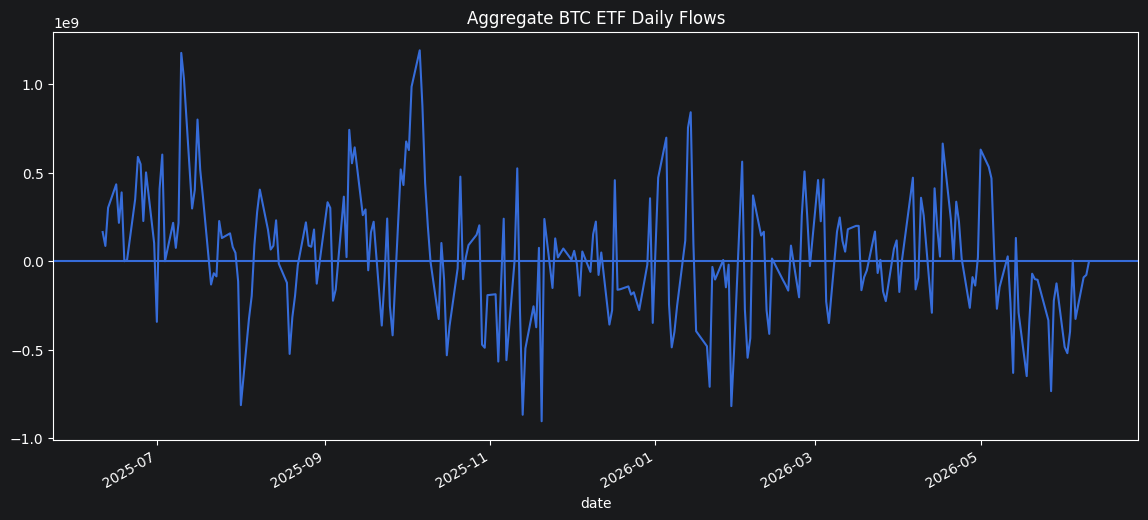

In [4199]:
# Visualize ETF Flows

etf_flows_recent['btc_etf_flow_usd'].plot(figsize=(14,6))
plt.axhline(0)
plt.title('Aggregate BTC ETF Daily Flows')
plt.show()

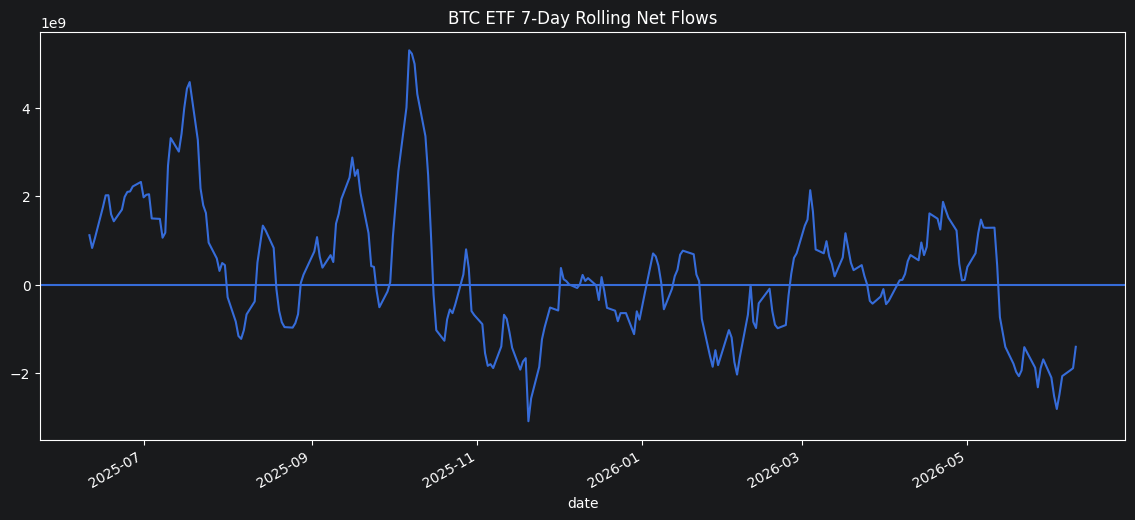

In [4200]:
etf_flows_recent['btc_etf_flow_7d'].plot(figsize=(14,6))
plt.axhline(0)
plt.title('BTC ETF 7-Day Rolling Net Flows')
plt.savefig(
    '../outputs/charts/rolling_etf_flows.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

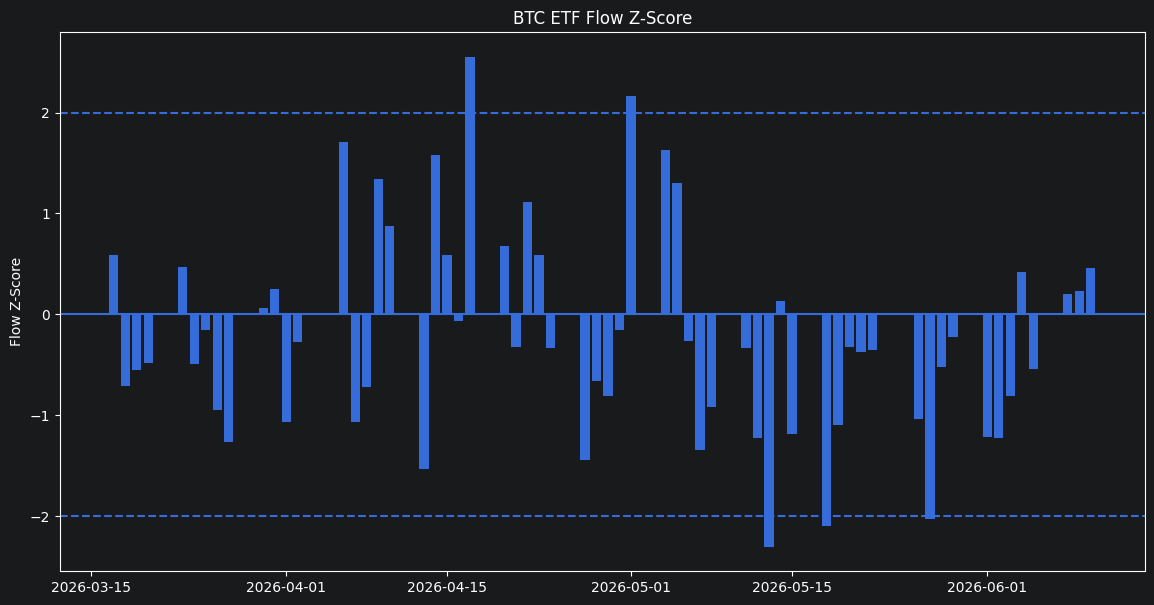

In [4201]:
# Recent ETF Flow Z-Scores

recent_flows = etf_flows_recent[['btc_etf_flow_zscore']].tail(60)

plt.figure(figsize=(14,7))

plt.bar(recent_flows.index, recent_flows['btc_etf_flow_zscore'])

plt.axhline(0)
plt.axhline(2, linestyle='--')
plt.axhline(-2, linestyle='--')

plt.title('BTC ETF Flow Z-Score')
plt.ylabel('Flow Z-Score')
plt.savefig(
    '../outputs/charts/etf_flow_zscore.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

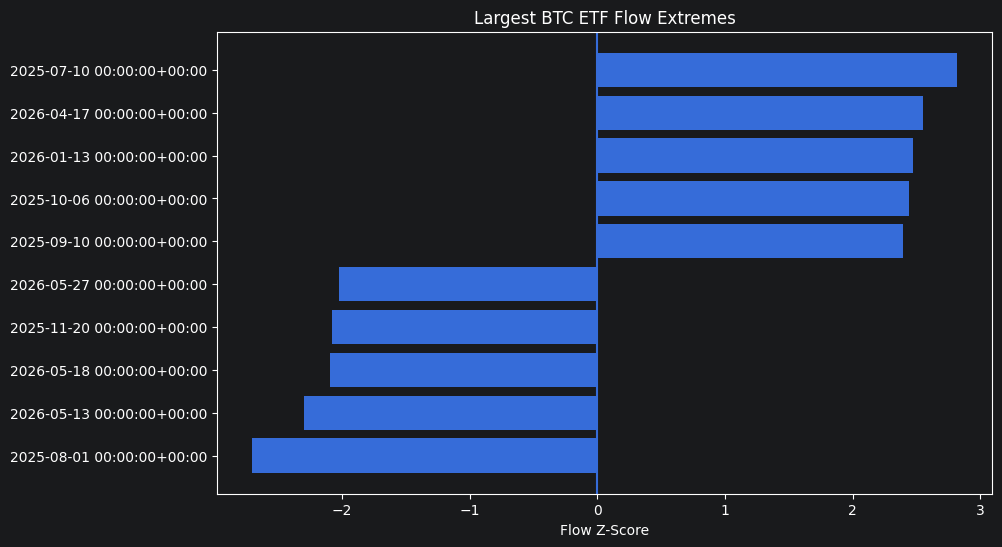

In [4202]:
# Largest Positive/Negative Flow Days

extreme_flows = etf_flows_recent[['btc_etf_flow_zscore']].dropna().sort_values(by='btc_etf_flow_zscore')

extreme_flows = pd.concat([
    extreme_flows.head(5),
    extreme_flows.tail(5)
])

plt.figure(figsize=(10,6))

plt.barh(extreme_flows.index.astype(str), extreme_flows['btc_etf_flow_zscore'])

plt.axvline(0)
plt.title('Largest BTC ETF Flow Extremes')
plt.xlabel('Flow Z-Score')
plt.show()

In [4203]:
# Merge ETF flows into prices

prices = prices.merge(etf_flows_recent[
        ['btc_etf_flow_usd',
        'btc_etf_flow_7d',
        'btc_etf_flow_30d',
        'btc_etf_flow_zscore']],
    on='date', how='left', validate='one_to_one'
)

In [4204]:
# Shift ETF flow metrics for report-card alignment.
# Raw ETF columns remain unshifted for research/diagnostics.

prices['btc_etf_flow_usd_shifted'] = prices['btc_etf_flow_usd'].shift(1)
prices['btc_etf_flow_7d_shifted'] = prices['btc_etf_flow_7d'].shift(1)
prices['btc_etf_flow_30d_shifted'] = prices['btc_etf_flow_30d'].shift(1)
prices['btc_etf_flow_zscore_shifted'] = prices['btc_etf_flow_zscore'].shift(1)

In [4205]:
# Institutional Flow Regimes - Research Version
# Uses unshifted ETF flow z-score for forward-return analysis.

prices['institutional_signal_research'] = 'Neutral'

prices.loc[
    prices['btc_etf_flow_zscore'] > 1.5,
    'institutional_signal_research'
] = 'Strong Institutional Inflows'

prices.loc[
    prices['btc_etf_flow_zscore'] < -1.5,
    'institutional_signal_research'
] = 'Institutional Outflows'

In [4206]:
# Institutional Flow Regimes

prices['institutional_signal'] = 'Neutral'

prices.loc[
    prices['btc_etf_flow_zscore_shifted'] > 1.5,
    'institutional_signal'
] = 'Strong Institutional Inflows'

prices.loc[
    prices['btc_etf_flow_zscore_shifted'] < -1.5,
    'institutional_signal'
] = 'Institutional Outflows'

In [4207]:
# Plotting Market Drivers

# Start Neutral
prices['market_driver'] = 'Neutral'

# Lowest priority first
prices.loc[
    (prices['institutional_signal'] == 'Strong Institutional Inflows') &
    (prices['leverage_signal'] == 'Neutral'),
    'market_driver'
] = 'Spot-Led Institutional Demand'

prices.loc[
    (prices['institutional_signal'] == 'Neutral') &
    (prices['leverage_signal'] == 'Aggressive Long Buildup'),
    'market_driver'
] = 'Leverage-Driven Rally'

# Higher priority
prices.loc[
    (prices['institutional_signal'] == 'Strong Institutional Inflows') &
    (prices['leverage_signal'] == 'Aggressive Long Buildup'),
    'market_driver'
] = 'Institutional + Leverage Momentum'

# Highest priority LAST
prices.loc[
    (prices['institutional_signal'] == 'Institutional Outflows') |
    (prices['leverage_signal'] == 'Long Liquidation'),
    'market_driver'
] = 'Risk-Off / Deleveraging'

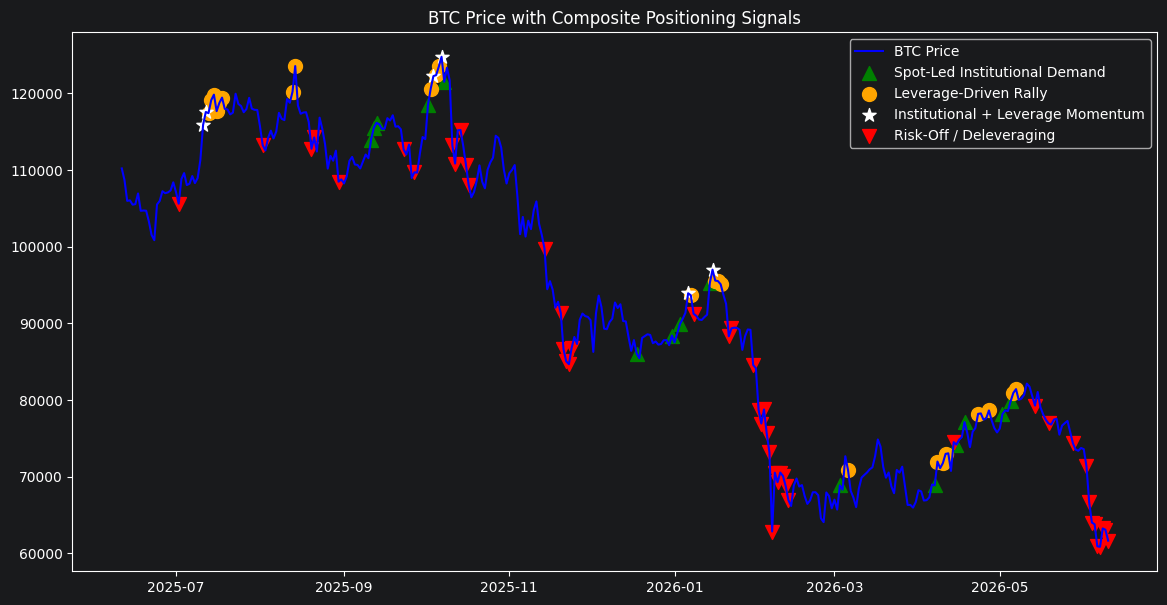

In [4208]:
signal_df = prices[prices['market_driver'] != 'Neutral']

plt.figure(figsize=(14,7))

plt.plot(prices.index, prices['price'], color='blue', label='BTC Price')

marker_map = {
    'Spot-Led Institutional Demand': ('^', 'green'),
    'Leverage-Driven Rally': ('o', 'orange'),
    'Institutional + Leverage Momentum': ('*', 'white'),
    'Risk-Off / Deleveraging': ('v', 'red')
}

for signal, (marker, color) in marker_map.items():
    subset = signal_df[signal_df['market_driver'] == signal]

    plt.scatter(
        subset.index,
        subset['price'],
        label=signal,
        marker=marker,
        color=color,
        s=100
    )

plt.title('BTC Price with Composite Positioning Signals')
plt.legend()
plt.savefig(
    '../outputs/charts/composite_positioning_signals.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

In [4209]:
# 6. Pull BTC liquidation data

liquidation_url = (
    "https://open-api-v4.coinglass.com"
    "/api/futures/liquidation/aggregated-history"
)

headers = {
    "accept": "application/json",
    "CG-API-KEY": os.getenv("COINGLASS_API_KEY")
}

params = {
    "symbol": "BTC",
    "interval": "1d",
    "exchange_list": "Binance"
}

response = requests.get(
    liquidation_url,
    headers=headers,
    params=params
)

response.raise_for_status()

liquidation_data = response.json()

In [4210]:
liquidations = pd.DataFrame(liquidation_data['data'])

liquidations['time'] = pd.to_datetime(liquidations['time'], unit='ms', utc=True)

liquidations = liquidations.rename(columns={
    'time':'date',
    'aggregated_long_liquidation_usd':'long_liquidations_usd',
    'aggregated_short_liquidation_usd':'short_liquidations_usd'
})

liquidations = liquidations[
    [
        'date',
        'long_liquidations_usd',
        'short_liquidations_usd'
    ]
]

liquidations = liquidations.set_index('date')

liquidations['total_liquidations_usd'] = liquidations['long_liquidations_usd'] + liquidations['short_liquidations_usd']

In [4211]:
liquidations['long_liq_zscore'] = (liquidations['long_liquidations_usd'] - liquidations['long_liquidations_usd'].rolling(30).mean()) / liquidations['long_liquidations_usd'].rolling(30).std()
liquidations['short_liq_zscore'] = (liquidations['short_liquidations_usd'] - liquidations['short_liquidations_usd'].rolling(30).mean()) / liquidations['short_liquidations_usd'].rolling(30).std()

In [4212]:
# Filter dataset for trailing 365 days

cutoff_date = pd.Timestamp.now(tz='UTC') - pd.Timedelta(days=365)

liquidations_recent = liquidations[
    liquidations.index >= cutoff_date
].copy()

In [4213]:
prices = prices.merge(liquidations_recent, on='date', how='left', validate='one_to_one')

In [4214]:
prices['long_liq_zscore_shifted'] = (
    prices['long_liq_zscore']
    .shift(1)
)

prices['short_liq_zscore_shifted'] = (
    prices['short_liq_zscore']
    .shift(1)
)

In [4215]:
prices['liquidation_signal'] = 'Neutral'

prices.loc[
    (prices['long_liq_zscore_shifted'] > 1) &
    (prices['short_liq_zscore_shifted'] <= 1),
    'liquidation_signal'
] = 'Elevated Long Liquidation'

prices.loc[
    (prices['short_liq_zscore_shifted'] > 1) &
    (prices['long_liq_zscore_shifted'] <= 1),
    'liquidation_signal'
] = 'Elevated Short Liquidation'

prices.loc[
    (prices['long_liq_zscore_shifted'] > 1) &
    (prices['short_liq_zscore_shifted'] > 1),
    'liquidation_signal'
] = 'Two-Sided Liquidation Event'

In [4216]:
prices['liquidation_signal_research'] = 'Neutral'

prices.loc[
    (prices['long_liq_zscore'] > 1) &
    (prices['short_liq_zscore'] <= 1),
    'liquidation_signal_research'
] = 'Elevated Long Liquidation'

prices.loc[
    (prices['short_liq_zscore'] > 1) &
    (prices['long_liq_zscore'] <= 1),
    'liquidation_signal_research'
] = 'Elevated Short Liquidation'

prices.loc[
    (prices['long_liq_zscore'] > 1) &
    (prices['short_liq_zscore'] > 1),
    'liquidation_signal_research'
] = 'Two-Sided Liquidation Event'

In [4217]:
# Refine Market Driver with Liquidation Confirmation

prices.loc[
    (prices['market_driver'] == 'Risk-Off / Deleveraging') &
    (prices['liquidation_signal'] == 'Elevated Long Liquidation'),
    'market_driver'
] = 'Risk-Off / Forced Deleveraging'

prices.loc[
    (prices['market_driver'] == 'Leverage-Driven Rally') &
    (prices['liquidation_signal'] == 'Elevated Short Liquidation'),
    'market_driver'
] = 'Short Squeeze / Forced Buying'

In [4218]:
# 6. Run conditional forward-return analysis

prices['forward_7d_return'] = (prices['price'].shift(-7) / prices['price']) - 1
prices['forward_30d_return'] = (prices['price'].shift(-30) / prices['price']) - 1

In [4219]:
# All signal subsets — taken AFTER forward-return columns exist
strong_etf_inflows = prices[prices['institutional_signal_research'] == 'Strong Institutional Inflows']
long_buildup = prices[prices['leverage_signal'] == 'Aggressive Long Buildup']
long_liquidation = prices[prices['leverage_signal'] == 'Long Liquidation']
short_buildup = prices[prices['leverage_signal'] == 'Aggressive Short Buildup']
short_covering = prices[prices['leverage_signal'] == 'Short Covering Rally']
elevated_long_liq = prices[prices['liquidation_signal_research'] == 'Elevated Long Liquidation']
elevated_short_liq = prices[prices['liquidation_signal_research'] == 'Elevated Short Liquidation']
two_sided_liq = prices[prices['liquidation_signal_research'] == 'Two-Sided Liquidation Event']

In [4220]:
etf_median = strong_etf_inflows[['forward_7d_return', 'forward_30d_return']].median()
long_median = long_buildup[['forward_7d_return', 'forward_30d_return']].median()
long_liquidation_median = long_liquidation[['forward_7d_return', 'forward_30d_return']].median()
short_buildup_median = short_buildup[['forward_7d_return', 'forward_30d_return']].median()
short_covering_median = short_covering[['forward_7d_return', 'forward_30d_return']].median()

print(
    f"Strong ETF Inflows | "
    f"Median 7D: {etf_median['forward_7d_return']:.2%} | "
    f"Median 30D: {etf_median['forward_30d_return']:.2%}"
)

print(
    f"Aggressive Long Buildup | "
    f"Median 7D: {long_median['forward_7d_return']:.2%} | "
    f"Median 30D: {long_median['forward_30d_return']:.2%}"
)

print(
    f"Aggressive Long Liquidation | "
    f"Median 7D: {long_liquidation_median['forward_7d_return']:.2%} | "
    f"Median 30D: {long_liquidation_median['forward_30d_return']:.2%}"
)

print(
    f"Aggressive Short Buildup | "
    f"Median 7D: {short_buildup_median['forward_7d_return']:.2%} | "
    f"Median 30D: {short_buildup_median['forward_30d_return']:.2%}"
)

print(
    f"Short Covering Rally | "
    f"Median 7D: {short_covering_median['forward_7d_return']:.2%} | "
    f"Median 30D: {short_covering_median['forward_30d_return']:.2%}"
)

Strong ETF Inflows | Median 7D: 2.00% | Median 30D: -3.67%
Aggressive Long Buildup | Median 7D: -1.24% | Median 30D: -5.51%
Aggressive Long Liquidation | Median 7D: -2.39% | Median 30D: -3.57%
Aggressive Short Buildup | Median 7D: 3.24% | Median 30D: -12.10%
Short Covering Rally | Median 7D: -1.76% | Median 30D: -3.94%


In [4221]:
# Summary of Signals

signal_summary = pd.DataFrame({
    'signal': [
        'Strong ETF Inflows',
        'Aggressive Long Buildup',
        'Long Liquidation',
        'Aggressive Short Buildup',
        'Short Covering Rally',
        'Elevated Long Liquidation',
        'Elevated Short Liquidation'
    ],
    'obs_7d': [
        strong_etf_inflows['forward_7d_return'].count(),
        long_buildup['forward_7d_return'].count(),
        long_liquidation['forward_7d_return'].count(),
        short_buildup['forward_7d_return'].count(),
        short_covering['forward_7d_return'].count(),
        elevated_long_liq['forward_7d_return'].count(),
        elevated_short_liq['forward_7d_return'].count()
    ],
    'obs_30d': [
        strong_etf_inflows['forward_30d_return'].count(),
        long_buildup['forward_30d_return'].count(),
        long_liquidation['forward_30d_return'].count(),
        short_buildup['forward_30d_return'].count(),
        short_covering['forward_30d_return'].count(),
        elevated_long_liq['forward_30d_return'].count(),
        elevated_short_liq['forward_30d_return'].count()
    ],
    'median_7d_return': [
        strong_etf_inflows['forward_7d_return'].median(),
        long_buildup['forward_7d_return'].median(),
        long_liquidation['forward_7d_return'].median(),
        short_buildup['forward_7d_return'].median(),
        short_covering['forward_7d_return'].median(),
        elevated_long_liq['forward_7d_return'].median(),
        elevated_short_liq['forward_7d_return'].median()
    ],
    'median_30d_return': [
        strong_etf_inflows['forward_30d_return'].median(),
        long_buildup['forward_30d_return'].median(),
        long_liquidation['forward_30d_return'].median(),
        short_buildup['forward_30d_return'].median(),
        short_covering['forward_30d_return'].median(),
        elevated_long_liq['forward_30d_return'].median(),
        elevated_short_liq['forward_30d_return'].median()
    ]
})

In [4222]:
signal_summary_raw = signal_summary.copy()
signal_summary_display = signal_summary.copy()

In [4223]:
signal_summary_display = signal_summary_display.sort_values('median_7d_return', ascending=False).reset_index(drop=True)

signal_summary_display['median_7d_return'] = signal_summary_display['median_7d_return'].map('{:.2%}'.format)
signal_summary_display['median_30d_return'] = signal_summary_display['median_30d_return'].map('{:.2%}'.format)

print(signal_summary_display)

                       signal  obs_7d  obs_30d median_7d_return  \
0    Aggressive Short Buildup       8        8            3.24%   
1  Elevated Short Liquidation      38       38            2.33%   
2          Strong ETF Inflows      22       22            2.00%   
3     Aggressive Long Buildup      30       30           -1.24%   
4        Short Covering Rally      13       13           -1.76%   
5            Long Liquidation      27       25           -2.39%   
6   Elevated Long Liquidation      38       29           -3.98%   

  median_30d_return  
0           -12.10%  
1             0.82%  
2            -3.67%  
3            -5.51%  
4            -3.94%  
5            -3.57%  
6            -3.57%  


In [4224]:
# 7. BTC Daily Positioning Report

latest = prices.iloc[-1]
latest_date = prices.index[-1]

# ETF display logic for weekends / holidays / unavailable data
if pd.isna(latest['btc_etf_flow_zscore_shifted']):
    etf_zscore_display = "Unavailable"
    institutional_signal_display = "Unavailable - U.S. market closed"
else:
    etf_zscore_display = f"{latest['btc_etf_flow_zscore_shifted']:.1f}"
    institutional_signal_display = latest['institutional_signal']

In [4225]:
report_date = pd.Timestamp.today().date()
market_date = (latest_date - pd.Timedelta(days=1)).date()

print("BTC DAILY POSITIONING REPORT")
print("-" * 35)
print(f"Generated: {report_date}")
print(f"Market Data Through: {market_date}")

print("\nPRICE")
print(f"BTC Price: ${latest['price']:,.0f}")
print(f"1D Return: {latest['daily_return']:.1%}")
print(f"7D Return: {latest['7d_return']:.1%}")
print(f"30D Return: {latest['30d_return']:.1%}")
print(f"Rolling 7D Volatility: {latest['rolling_vol_7d']:.1%}")

print("\nINSTITUTIONAL DEMAND")
print(f"ETF Flow Z-Score: {etf_zscore_display}")
print(f"Institutional Signal: {institutional_signal_display}")

print("\nLEVERAGE POSITIONING")
print(f"Funding Rate: {latest['funding_rate']:.4%}")
print(f"Funding Z-Score: {latest['funding_zscore']:.1f}")
print(f"OI Z-Score: {latest['oi_zscore']:.1f}")
print(f"OI 7D Change: {latest['oi_7d_change']:.1%}")
print(f"Leverage Signal: {latest['leverage_signal']}")

print("\nLIQUIDATION ACTIVITY")
print(f"Long Liquidation Z-Score: {latest['long_liq_zscore_shifted']:.1f}")
print(f"Short Liquidation Z-Score: {latest['short_liq_zscore_shifted']:.1f}")
print(f"Liquidation Signal: {latest['liquidation_signal']}")

print("\nPRIMARY MARKET REGIME IDENTIFICATION")
print(f"{latest['market_driver']}")



BTC DAILY POSITIONING REPORT
-----------------------------------
Generated: 2026-06-10
Market Data Through: 2026-06-09

PRICE
BTC Price: $61,658
1D Return: -2.3%
7D Return: -7.5%
30D Return: -24.9%
Rolling 7D Volatility: 2.8%

INSTITUTIONAL DEMAND
ETF Flow Z-Score: 0.2
Institutional Signal: Neutral

LEVERAGE POSITIONING
Funding Rate: 0.0003%
Funding Z-Score: -0.3
OI Z-Score: -1.5
OI 7D Change: -6.7%
Leverage Signal: Long Liquidation

LIQUIDATION ACTIVITY
Long Liquidation Z-Score: -0.1
Short Liquidation Z-Score: -0.2
Liquidation Signal: Neutral

PRIMARY MARKET REGIME IDENTIFICATION
Risk-Off / Deleveraging


In [4226]:
# ETF flows and liquidation data are shifted by one day.
# CoinGecko prices represent a daily snapshot at 00:00 UTC,
# while ETF flows and liquidation totals represent activity
# occurring throughout the prior trading day.
# Shifting aligns activity-based metrics with the subsequent
# price observation used in the positioning report.

In [4227]:
# =============================================================================
# AI POSITIONING COMMENTARY
# =============================================================================

In [4228]:
from openai import OpenAI
from dotenv import load_dotenv
import os
import json
from pathlib import Path

load_dotenv()

client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY")
)

In [4229]:
SYSTEM_MESSAGE = """
You are a crypto market structure analyst writing concise institutional-style Bitcoin positioning commentary.

You interpret structured daily positioning reports using:
- BTC price action
- ETF flows
- funding rates
- open interest
- liquidation activity
- volatility
- market regime signals

Write like an institutional crypto strategist.
Do not simply restate the report card.
Focus on interpretation rather than repeating statistics.
Explain what the combination of signals suggests about market positioning and market structure.
Assume the reader already has access to all reported metrics.
Avoid defining funding rates, open interest, ETF flows, or liquidation data.
Write concise research commentary similar to what would be distributed to institutional clients.

Do not simply restate the report card.
Focus on interpretation rather than repeating statistics.
Assume the reader already has access to all reported metrics.
Avoid defining funding rates, open interest, ETF flows, or liquidation data.
Write concise research commentary similar to what would be distributed to institutional clients.\

Do not discuss each signal independently.
Instead, synthesize the signals into a single market narrative.
Your primary goal is to explain why the market moved based on the interaction between price action, leverage positioning, institutional flows, and liquidation activity.
Focus on relationships between signals rather than individual metrics.

Avoid phrases such as:
- "The ETF flow z-score indicates..."
- "The funding rate suggests..."
- "The liquidation signal shows..."
Instead explain what the combination of signals implies about market positioning and market structure.

Write from the perspective of a positioning analyst.
Prioritize positioning, flows, leverage, and market structure over price commentary.
Do not lead with price performance.
Assume the reader already knows the market moved.
Focus on explaining what positioning data suggests about the move.

ETF flow interpretation rule:
If institutional_signal is Neutral during a selloff, say the selloff was not primarily driven by institutional spot selling or ETF-related supply.
Do NOT say neutral ETF flows mean a lack of institutional buying interest.
If institutional_signal is Institutional Outflows during a selloff, say ETF flows reinforced downside pressure.
If institutional_signal is Strong Institutional Inflows during a selloff, say institutional demand provided offsetting support but was not enough to prevent the move lower.

When ETF flows are neutral during a selloff, phrase it as:
"institutional flows did not appear to be a primary source of sell pressure."
Avoid saying:
"institutional demand did not exacerbate the selloff."

ETF weekend / holiday rule:
ETF flow data only updates on U.S. market trading days.
If ETF flow fields are NaN, missing, zero because of a weekend/holiday, or explicitly marked unavailable, do not interpret ETF flows as neutral, positive, or negative.
Instead say:
"ETF flow data was unavailable due to the U.S. market calendar."

Do not infer institutional demand from missing ETF data.

Funding interpretation rule:
Always distinguish between the absolute funding rate and the funding z-score.
Funding z-score measures funding relative to recent history, not absolute positioning.
If funding_rate is near zero but funding_zscore is positive, describe funding as modest in absolute terms but elevated relative to recent history.
A positive funding z-score suggests residual long bias remains in the market.
A negative funding z-score suggests residual short bias remains in the market.
Do not describe positive funding as "cautious sentiment."

Do not make investment recommendations.
Do not predict price targets.
Do not overstate statistical confidence.

Prioritize:
1. Primary market driver
2. Leverage positioning
3. Institutional demand
4. Liquidation activity
5. Key risk to monitor next
"""

example_user_message = """
Generate institutional-style BTC positioning commentary from this report.

Report:

BTC DAILY POSITIONING REPORT
-----------------------------------
Generated: 2026-06-04
Market Data Through: 2026-06-03

PRICE
BTC Price: $64,022
1D Return: -3.9%
7D Return: -13.9%
30D Return: -19.8%
Rolling 7D Volatility: 2.6%

INSTITUTIONAL DEMAND
ETF Flow Z-Score: -0.8
Institutional Signal: Neutral

LEVERAGE POSITIONING
Funding Z-Score: 0.2
OI Z-Score: -2.8
OI 7D Change: -17.3%
Leverage Signal: Long Liquidation

LIQUIDATION ACTIVITY
Long Liquidation Z-Score: 1.1
Short Liquidation Z-Score: 0.0
Liquidation Signal: Elevated Long Liquidation

PRIMARY MARKET DRIVER
Risk-Off / Deleveraging
"""

example_assistant_message = """
DAILY BTC POSITIONING COMMENTARY

Summary:
The session was characterized by a meaningful unwind in leveraged long exposure. Falling open interest alongside elevated long liquidations suggests existing risk was being reduced rather than fresh short exposure being aggressively added. Funding remained close to neutral in absolute terms, though still elevated relative to recent history, suggesting some residual long bias remained in the market despite the broader deleveraging process. ETF flows were broadly neutral, indicating the move was primarily derivatives-led rather than institutionally driven.

Key Takeaways:
- The dominant regime was Risk-Off / Deleveraging.
- A sharp contraction in open interest points to exposure reduction rather than aggressive new short positioning.
- Elevated long liquidations suggest forced selling amplified the downside move.
- Neutral ETF flows imply the selloff was not primarily driven by institutional spot selling or ETF-related supply.
- Funding remained modest in absolute terms but elevated relative to recent history, suggesting some residual long bias remained in the system.

What To Watch:
- Whether open interest stabilizes following the recent deleveraging event.
- Whether funding normalizes further or remains elevated despite lower positioning levels.
- Whether ETF flows improve if BTC attempts to establish a base.
"""

report_card = f"""
BTC DAILY POSITIONING REPORT
-----------------------------------
Generated: {report_date}
Market Data Through: {market_date}

PRICE
BTC Price: ${latest['price']:,.0f}
1D Return: {latest['daily_return']:.1%}
7D Return: {latest['7d_return']:.1%}
30D Return: {latest['30d_return']:.1%}
Rolling 7D Volatility: {latest['rolling_vol_7d']:.1%}

INSTITUTIONAL DEMAND
ETF Flow Z-Score: {etf_zscore_display}
Institutional Signal: {institutional_signal_display}

LEVERAGE POSITIONING
Funding Rate: {latest['funding_rate']:.1%}
Funding Z-Score: {latest['funding_zscore']:.1f}
OI Z-Score: {latest['oi_zscore']:.1f}
OI 7D Change: {latest['oi_7d_change']:.1%}
Leverage Signal: {latest['leverage_signal']}

LIQUIDATION ACTIVITY
Long Liquidation Z-Score: {latest['long_liq_zscore_shifted']:.1f}
Short Liquidation Z-Score: {latest['short_liq_zscore_shifted']:.1f}
Liquidation Signal: {latest['liquidation_signal']}

PRIMARY MARKET DRIVER
{latest['market_driver']}
"""

user_message = f"""
Generate institutional-style BTC positioning commentary from this report.

Use the following format:

DAILY BTC POSITIONING COMMENTARY

Summary:
[3-5 sentences]

Key Takeaways:
- bullet
- bullet
- bullet

What To Watch:
- bullet
- bullet

Report:

{report_card}
"""

response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": SYSTEM_MESSAGE},
        {"role": "user", "content": example_user_message},
        {"role": "assistant", "content": example_assistant_message},
        {"role": "user", "content": user_message}
    ],
    temperature=0.2,
    max_completion_tokens=700
)

print(response.choices[0].message.content)

DAILY BTC POSITIONING COMMENTARY

Summary:
The market continues to exhibit a Risk-Off / Deleveraging environment, with BTC experiencing a notable decline in both price and open interest. The neutral institutional signal alongside slightly positive ETF flows suggests that institutional demand is not a primary driver of the current price action. Long liquidations remain subdued, indicating that while some forced selling has occurred, it has not reached elevated levels that would typically exacerbate downside momentum.

Key Takeaways:
- The decline in open interest reflects a cautious approach among traders, with a focus on reducing leverage rather than adding new positions.
- Neutral liquidation signals indicate that the market is not under significant stress from forced liquidations, which may provide a buffer against further downside.
- ETF flows remain neutral, suggesting institutional participation is stable but not aggressive enough to counteract the prevailing risk-off sentiment.



In [4230]:
ai_commentary = response.choices[0].message.content

log_file = Path("commentary_log.json")

if log_file.exists():
    with open(log_file, "r") as f:
        commentary_log = json.load(f)
else:
    commentary_log = []

new_entry = {
    "date": str(report_date),
    "market_data_through": str(market_date),

    "price": float(latest["price"]),
    "price_return_1d": float(latest["daily_return"]),
    "price_return_7d": float(latest["7d_return"]),
    "price_return_30d": float(latest["30d_return"]),
    "rolling_vol_7d": float(latest["rolling_vol_7d"]),

    "funding_rate": round(float(latest["funding_rate"]), 8),
    "funding_zscore": float(latest["funding_zscore"]),

    "oi_zscore": float(latest["oi_zscore"]),
    "oi_7d_change": float(latest["oi_7d_change"]),

    "btc_etf_flow_zscore": (
        None
        if pd.isna(latest["btc_etf_flow_zscore_shifted"])
        else float(latest["btc_etf_flow_zscore_shifted"])
    ),

    "institutional_signal": institutional_signal_display,

    "long_liq_zscore": float(latest["long_liq_zscore_shifted"]),
    "short_liq_zscore": float(latest["short_liq_zscore_shifted"]),

    "market_driver": latest["market_driver"],
    "leverage_signal": latest["leverage_signal"],
    "liquidation_signal": latest["liquidation_signal"],

    "commentary": ai_commentary
}

commentary_log.append(new_entry)

with open(log_file, "w") as f:
    json.dump(commentary_log, f, indent=4)

print(f"Entries in log: {len(commentary_log)}")
print(commentary_log[-1])

Entries in log: 6
{'date': '2026-06-10', 'market_data_through': '2026-06-09', 'price': 61658.311991466595, 'price_return_1d': -0.022513690766515992, 'price_return_7d': -0.07489203962160984, 'price_return_30d': -0.24940264716209992, 'rolling_vol_7d': 0.02844656497029333, 'funding_rate': 3.36e-06, 'funding_zscore': -0.31438679544801285, 'oi_zscore': -1.508342480493004, 'oi_7d_change': -0.06710784677215131, 'btc_etf_flow_zscore': 0.2275831296145422, 'institutional_signal': 'Neutral', 'long_liq_zscore': -0.09952277499545821, 'short_liq_zscore': -0.17200244736879128, 'market_driver': 'Risk-Off / Deleveraging', 'leverage_signal': 'Long Liquidation', 'liquidation_signal': 'Neutral', 'commentary': 'DAILY BTC POSITIONING COMMENTARY\n\nSummary:\nThe market continues to exhibit a Risk-Off / Deleveraging environment, with BTC experiencing a notable decline in both price and open interest. The neutral institutional signal alongside slightly positive ETF flows suggests that institutional demand is n

In [4231]:
# BTC Daily Positioning Report + AI Positioning Commentary

print(report_card)

print("\nAI POSITIONING COMMENTARY")
print("-" * 35)
print(ai_commentary)


BTC DAILY POSITIONING REPORT
-----------------------------------
Generated: 2026-06-10
Market Data Through: 2026-06-09

PRICE
BTC Price: $61,658
1D Return: -2.3%
7D Return: -7.5%
30D Return: -24.9%
Rolling 7D Volatility: 2.8%

INSTITUTIONAL DEMAND
ETF Flow Z-Score: 0.2
Institutional Signal: Neutral

LEVERAGE POSITIONING
Funding Rate: 0.0%
Funding Z-Score: -0.3
OI Z-Score: -1.5
OI 7D Change: -6.7%
Leverage Signal: Long Liquidation

LIQUIDATION ACTIVITY
Long Liquidation Z-Score: -0.1
Short Liquidation Z-Score: -0.2
Liquidation Signal: Neutral

PRIMARY MARKET DRIVER
Risk-Off / Deleveraging


AI POSITIONING COMMENTARY
-----------------------------------
DAILY BTC POSITIONING COMMENTARY

Summary:
The market continues to exhibit a Risk-Off / Deleveraging environment, with BTC experiencing a notable decline in both price and open interest. The neutral institutional signal alongside slightly positive ETF flows suggests that institutional demand is not a primary driver of the current price act

In [4232]:
# Experimental: Contextual Commentary Using Prior History

with open(log_file, "r") as f:
    commentary_log = json.load(f)

recent_history = [
    entry for entry in commentary_log
    if "funding_rate" in entry
][-5:]

history_context = ""

for entry in recent_history:
    history_context += f"""
Date Generated: {entry['date']}
Market Data Through: {entry['market_data_through']}
1D Return: {entry['price_return_1d']:.1%}
7D Return: {entry['price_return_7d']:.1%}
30D Return: {entry['price_return_30d']:.1%}
Funding Rate: {entry['funding_rate']:.4%}
Funding Z-Score: {entry['funding_zscore']:.1f}
OI Z-Score: {entry['oi_zscore']:.1f}
OI 7D Change: {entry['oi_7d_change']:.1%}
ETF Flow Z-Score: {entry['btc_etf_flow_zscore']}
Institutional Signal: {entry['institutional_signal']}
Long Liq Z-Score: {entry['long_liq_zscore']:.1f}
Short Liq Z-Score: {entry['short_liq_zscore']:.1f}
Market Driver: {entry['market_driver']}
Leverage Signal: {entry['leverage_signal']}
Liquidation Signal: {entry['liquidation_signal']}

Prior Commentary:
{entry['commentary']}

---
"""

In [4233]:
contextual_user_message = f"""
Generate institutional-style BTC positioning commentary from today's report.

Use the recent history to compare today's market structure with prior sessions when relevant.

Focus on:
- Whether the market regime is persisting or changing
- Whether leverage conditions are improving or deteriorating
- Whether liquidation activity is increasing, fading, or shifting from long liquidations to short liquidations
- Whether institutional participation is becoming more or less important
- Whether today's move looks like trend continuation, stabilization, or a counter-trend squeeze

Do not force comparisons if they are not meaningful.

Always structure the response using the following sections:

Summary:
A concise explanation of today's market structure and how it compares to recent sessions.

Key Takeaways:
3-5 bullet points highlighting the most important positioning developments.

What To Watch:
2-3 forward-looking observations describing the most important risks, positioning shifts, or catalysts to monitor.

Recent History:
{history_context}

Today's Report:
{report_card}
"""

In [4234]:
contextual_example_user_message = """
Recent History:

Day 1:
BTC -6.0%
OI 7D Change: -18.0%
Liquidation Signal: Two-Sided Liquidation Event
Market Driver: Risk-Off / Deleveraging

Day 2:
BTC +4.0%
OI 7D Change: -17.0%
Liquidation Signal: Elevated Short Liquidation
Market Driver: Risk-Off / Deleveraging

Today's Report:

BTC +0.2%
OI 7D Change: -14.0%
Liquidation Signal: Neutral
Market Driver: Risk-Off / Deleveraging
"""

contextual_example_assistant_message = """
DAILY BTC POSITIONING COMMENTARY

Summary:
The market remains in a broader Risk-Off / Deleveraging regime, but liquidation dynamics have evolved meaningfully over recent sessions. Following a broad-based liquidation event and subsequent short-covering rally, liquidation activity has normalized. This suggests the market may be transitioning from an acute liquidation phase toward stabilization, although leverage conditions remain weak.

Key Takeaways:
- The broader deleveraging regime remains intact despite recent price stabilization.
- Liquidation activity has progressed from a two-sided liquidation event to a short squeeze and now back to neutral conditions.
- Open interest remains depressed, but the pace of contraction has improved, suggesting deleveraging pressure may be moderating.
- Recent price stabilization appears driven more by the fading of liquidation pressure than renewed risk appetite.

What To Watch:
- Whether open interest stabilizes after the recent deleveraging cycle.
- Whether leverage rebuilds through rising funding and open interest.
- Whether BTC can maintain gains without support from short-covering activity.
"""

contextual_response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": SYSTEM_MESSAGE},

        {"role": "user", "content": example_user_message},
        {"role": "assistant", "content": example_assistant_message},

        {"role": "user", "content": contextual_example_user_message},
        {"role": "assistant", "content": contextual_example_assistant_message},

        {"role": "user", "content": contextual_user_message}
],
    temperature=0.2,
    max_completion_tokens=900
)

contextual_commentary = contextual_response.choices[0].message.content

print("\nEXPERIMENTAL CONTEXTUAL COMMENTARY")
print("-" * 35)
print(contextual_commentary)


EXPERIMENTAL CONTEXTUAL COMMENTARY
-----------------------------------

DAILY BTC POSITIONING COMMENTARY

Summary:
The market continues to operate within a Risk-Off / Deleveraging framework, with today's slight price decline reflecting ongoing caution among traders. Open interest has decreased further, indicating a continued reduction in leveraged positions, though the pace of decline has moderated. Liquidation activity remains neutral, suggesting that while long positions are being unwound, there is no significant pressure from either side. Institutional participation appears stable but lacks the momentum to drive a reversal in sentiment.

Key Takeaways:
- The persistent risk-off environment is evident, with open interest continuing to decline, albeit at a slower rate than in previous sessions.
- Funding dynamics have shifted to a neutral stance, indicating a lack of strong directional bias among traders, which may reflect a cautious approach to new positions.
- Liquidation activity 